In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
camb_path = '/Users/chiaradeleo/Desktop/myeftcamb-main'
sys.path.insert(0,camb_path)
import camb
print(camb.__path__)

['/Users/chiaradeleo/myenv/lib/python3.9/site-packages/camb']


# Settings

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 10,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 10,
                     'lmax': 1500}

use_obs  = ['GC','WL']



## Preliminary calculations

Setting up some quantities that will be used later

In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 
#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

# Fiducial cosmology and CAMB settings

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            #'A_IA': 1.72,
            #'eta_IA': -0.41,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}

nuis_keys  = ['a0','a1', 'a2', 'a3', 'a4',  'b0_poly','b1_poly','b2_poly','b3_poly','omegam', 'omegab', 'sigma8']
cosmo_keys = [key for key in fiducial.keys() if key not in nuis_keys]

#camb_path = '/Users/chiaradeleo/myenv/lib/python3.12/site-packages'


# Galaxy distributions (external)

These cells create the galaxy distribution object that is needed by the obs computation.
We save all this info in a dictionary that will 

In [5]:
distributions = {}

## GC density

In [6]:
#check_Nbins = 10
#check_galdist_file = './input_files/nzTabISTF.dat'
#check_bin_lims = np.array([0.001, 0.417, 0.5593, 0.677, 0.787, 0.899, 1.017, 1.153, 1.322, 1.573, 3.])
#check_bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
#
#check_dist = pd.read_csv(galdist_file, skiprows=1, header=None, sep='\s+',
#                         names=['z']+['n{}'.format(i) for i in range(1,Nbins+1)])
#
#check_ni_interps = [interp1d(dist['z'], dist[col], fill_value=(0, 0), bounds_error=False)
#                    for col in dist.columns if col != 'z']

In [7]:
if 'GC' in use_obs:
    dist = galaxy_distribution(survey='Euclid-10')
    bin_lims = dist.galdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_gc = len(bin_lims)-1
    
    distributions['GC'] = {'dist': dist.galdict['binned_dist'],
                           'Nbins': Nbins_gc,
                           'zmean': bin_mids}


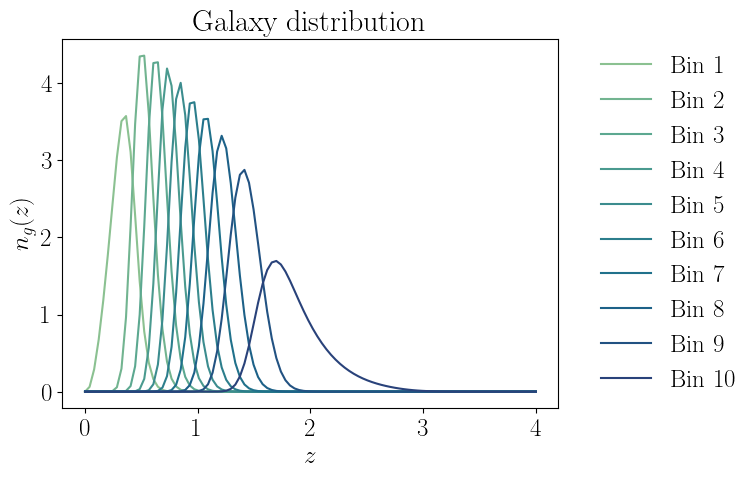

In [8]:
if 'GC' in use_obs:
    bincolors = sb.color_palette('crest',Nbins_gc)
    zplot = np.linspace(0.001,4,100)
    
    plt.figure()
    for i in range(Nbins_gc):
        plt.plot(zplot, distributions['GC']['dist'][i](zplot),color=bincolors[i],label=r'Bin {}'.format(i+1))
    plt.xlabel(r'$z$')
    plt.ylabel(r'$n_g(z)$')
    plt.legend(**sidelegend)
    plt.title('Galaxy distribution');

## WL density

In [9]:
if 'WL' in use_obs:
    dist = galaxy_distribution(survey='Euclid-10')
    bin_lims = dist.galdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_wl = len(bin_lims)-1
    
    distributions['WL'] = {'dist': dist.galdict['binned_dist'],
                           'Nbins': Nbins_wl,
                           'zmean': bin_mids}

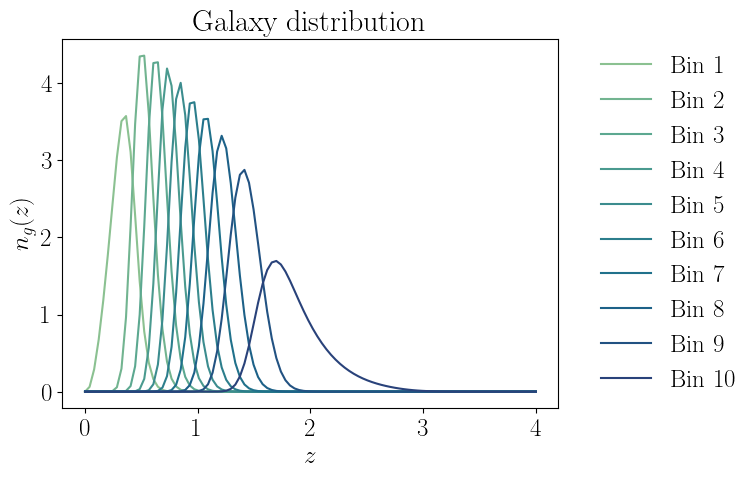

In [10]:
if 'WL' in use_obs:
    bincolors = sb.color_palette('crest',Nbins_wl)
    zplot = np.linspace(0.001,4,100)
    
    plt.figure()
    for i in range(Nbins_wl):
        plt.plot(zplot, distributions['WL']['dist'][i](zplot),color=bincolors[i],label=r'Bin {}'.format(i+1))
    plt.xlabel(r'$z$')
    plt.ylabel(r'$n_g(z)$')
    plt.legend(**sidelegend)
    plt.title('Galaxy distribution');

## GW density

In [11]:
#old implementation
sys.path.insert(0,'/Users/chiaradeleo/Desktop/6x2pt_IA_EFT_switch/source_code_old/')
if 'GW' in use_obs:
    from gwdist import gw_distribution
    
    gwdist  = gw_distribution()
    
    
    ngwbin = (GW_specs['N_gw']/(len(gwdist.z_bins)-1))
    Nbins_gw = len(gwdist.z_bins)-1
    
    bin_lims = gwdist.gwdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_wl = len(bin_lims)-1
    
    distributions['GW'] = {'dist': gwdist.ni_gw,
                           'Nbins': Nbins_gw,
                           'zmean': bin_mids}

In [12]:
if 'GW' in use_obs:
    zplot = np.linspace(0.001,4,100)
    
    plt.figure()
    #plt.plot(zplot,gwdist.Nz(zplot),color='black')
    for i in range(Nbins_gw):
        plt.plot(zplot,gwdist.ni_gw[i](zplot),color=bincolors[i],label=r'Bin {}'.format(i+1))
    
    plt.xlabel(r'$z$')
    plt.ylabel(r'$n_{gw}(z)$')
    plt.legend(**sidelegend)
    plt.title('Gravitational Waves distribution')

# Fiducial cosmological quantities

Here we create the cosmology dictionary to call

## Calling CAMB to get the cosmological quantities

This is done by the get_cosmo_dict function when calling the likelihood

In [13]:

import camb
print(camb.__path__)
stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
eft_params = {'EFTflag':0,}
                #'PureEFTmodel':1,
                 # 'PureEFTmodelOmega':3,
                  #'EFTOmega0':-0.019,
                  #'EFTOmegaExp':0.66}
eft_params.update(stability_flag)


['/Users/chiaradeleo/myenv/lib/python3.9/site-packages/camb']


In [14]:
data_root = './mock_data/'

if eft_params['EFTflag']==0:
    data_root = data_root+'LCDM_test_'
else:
    data_root = data_root+f'EFTflag_{eft_params["EFTflag"]}_test_'
if 'GC' in use_obs and 'WL' in use_obs:
    data_root = data_root+'gal'
elif 'GC' in use_obs:
    data_root = data_root+'GC'
elif 'WL' in use_obs:
    data_root = data_root+'WL'
if 'GW' in use_obs:
        data_root = data_root+'GW'
print(data_root)


./mock_data/LCDM_test_gal


## Create cosmology input for 

In [15]:
#zinterps = np.logspace(-3,np.log10(4),500)

#z0 = 0.001
#ks = 0.001
#P_z_k = Pk_interp.P(zinterps, ks)
#Dz    = np.sqrt(P_z_k / Pk_interp.P(z0, ks))

#Om = results.get_Omega('cdm')+results.get_Omega('baryon')+results.get_Omega('nu')

#cosmo_dict = {'cosmo_params': {k:v for k,v in fiducial.items() if k in cosmo_keys}}

#IA_poly=[sum([fiducial['a{}'.format(ind)]*np.power(z,ind) for ind in range(5)]) for z in zinterps]

#IA = -fiducial['A_IA']*0.0134*Om*(1+zinterps)**fiducial['eta_IA']/Dz
#cosmo_dict['IA_term']= interp1d(zinterps,IA_poly)

#bgrid = [sum([fiducial['b{}_poly'.format(ind)]*np.power(z,ind) for ind in range(4)]) for z in zinterps]
#cosmo_dict['bias'] = interp1d(zinterps,bgrid)
#cosmo_dict['eft_params']=eft_params

## Modelling check

to be added:
- check binned approach for IA and bias

# Observables computation

In [16]:
from source_code.compute_obs_sources import get_obs
extra=eft_params

In [17]:
calc_obs = get_obs(fiducial,extra,distributions,ells,camb_path,case='simple',source=True,feedback=True)



CAMB took 6.17 s
Cls packing took 0.05 s
Cls computed in 6.2 s


In [18]:
calc_obs2 = get_obs(fiducial,extra,distributions,ells,camb_path,case='simple',source=True,feedback=True)



CAMB took 5.78 s
Cls packing took 0.05 s
Cls computed in 5.8 s


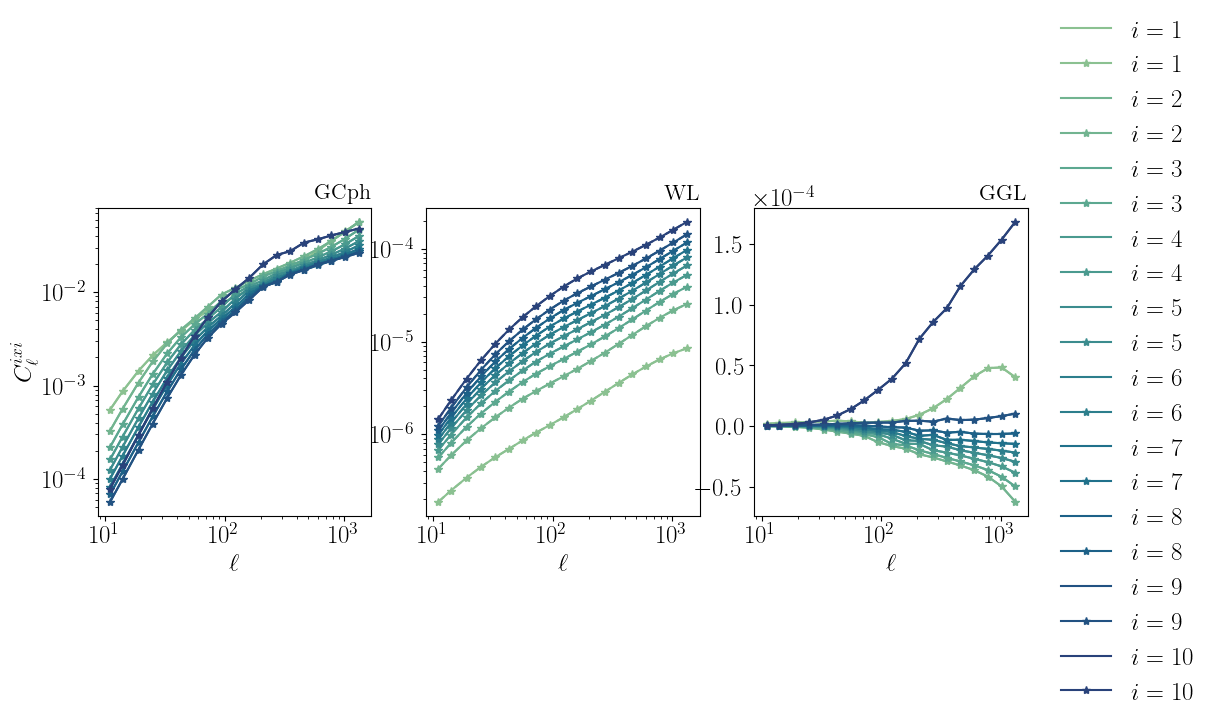

In [19]:
norm = ells*(ells+1)/(2*np.pi)
fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
#plt.suptitle('Fiducial Angupower spectra, old: (*), new: (-) ',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        axes[0].plot(ells,calc_obs2.Cls['G{}xG{}'.format(i,i)]*norm,marker='*',
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        axes[1].plot(ells,calc_obs2.Cls['L{}xL{}'.format(i,i)]*norm,marker='*',ls='--',
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs.Cls['G{}xL{}'.format(i,i)]*norm,
                    label=r'$i={}$'.format(i),color=bincolors[i-1])
        axes[2].plot(ells,calc_obs2.Cls['G{}xL{}'.format(i,i)]*norm,marker='*',
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')


axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
plt.savefig('Cls_old_new.pdf', bbox_inches='tight')
axes[-1].legend(**sidelegend);

In [20]:

norm = ells*(ells+1)/(2*np.pi)
if 'GW' in use_obs :
    Nbins=Nbins_gc
    fig, axes = plt.subplots(ncols=6, sharey=False, subplot_kw=dict(frameon=True), figsize=(21, 8))
    plt.suptitle('Fiducial power spectra', y=1.05, fontsize=20, fontweight='bold')
    
    axis_label_fontsize = 20
    title_fontsize = 20
    title_fontweight = 'bold'
    
    axes[0].set_title('GCph', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[0].plot(ells, calc_obs.Cls['G{}xG{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[0].plot(ells, calc_obs2.Cls['G{}xG{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[0].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
    axes[1].set_title('WL', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[1].plot(ells, calc_obs.Cls['L{}xL{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[1].plot(ells, calc_obs2.Cls['L{}xL{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[1].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
    axes[2].set_title('GW', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[2].plot(ells, calc_obs.Cls['W{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[2].plot(ells, calc_obs2.Cls['W{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[2].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    
    axes[3].set_title('GCph X WL', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[3].plot(ells, calc_obs.Cls['G{}xL{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[3].plot(ells, calc_obs2.Cls['G{}xL{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[3].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[3].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[3].set_xscale('log')
    
    axes[4].set_title('GCph x GW', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[4].plot(ells, calc_obs.Cls['G{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[4].plot(ells, calc_obs2.Cls['G{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[4].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[4].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[4].set_xscale('log')
    
    axes[5].set_title('WL x GW', loc='right', fontdict={'fontsize': title_fontsize, 'fontweight': title_fontweight})
    for i in range(1, Nbins + 1):
        axes[5].plot(ells, calc_obs.Cls['L{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1])
        axes[5].plot(ells, calc_obs2.Cls['L{}xW{}'.format(i, i)]*norm, label=r'$i={}$'.format(i), color=bincolors[i - 1], marker = '*')
    axes[5].set_xlabel(r'$\ell$', fontsize=axis_label_fontsize)
    axes[5].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[5].set_xscale('log')
    
    axes[0].set_ylabel(r'$\ell(\ell+1)/(2\pi)C_{ii}^{AB}(\ell)$', fontsize=axis_label_fontsize)
    plt.subplots_adjust(hspace=1.2)
    #axes[-1].legend(**sidelegend)
    
    

    plt.savefig('Cls.png', bbox_inches='tight');
    plt.show()


# Constructing covariance

**WARNING:** 
- currently setup for galaxies only
- assumes Gaussian covariance

In [21]:
from source_code.covariance_utils import covariance_einsum

#Nbins=Nbins_gc
Nell = {k: [0.]*len(ells) for k in calc_obs.Cls.columns}
j=0
for i in range(1,Nbins_wl+1):
    if 'GC' in use_obs and i<=Nbins_gc:
        ngalbin = (galaxy_specs['gal_per_arcmin']/Nbins_gc)*3600*(180/np.pi)**2
        Nell['G{}xG{}'.format(i,i)] = [(1/ngalbin)]*len(ells)
        

        #print(Nell['G{}xG{}'.format(i,i)])
    if 'WL' in use_obs:
        ngalbin = (galaxy_specs['gal_per_arcmin']/Nbins_wl)*3600*(180/np.pi)**2
        Nell['L{}xL{}'.format(i,i)] = [(galaxy_specs['sigma_eps']**2/ngalbin)]*len(ells)
        

    if 'GW' in use_obs:
        ngwbin = (GW_specs['N_gw']/(len(gwdist.z_bins)-1))
        Nell['W{}xW{}'.format(i,i)] = [(GW_specs['sigma_eps_gw']**2/ngwbin)]*len(ells)
        

#MMmod: can we account for different fsky in different probes??
fsky      = galaxy_specs['fsky'] 
Delta_ell = deltas

obs_list = []
if 'GC' in use_obs:
    obs_list.append('G')
    j+=1
if 'WL' in use_obs:
    obs_list.append('L')
    j+=1
if 'GW' in use_obs:
    obs_list.append('W')
    j+=1


err_for_cov = np.zeros((j,j,len(ells),Nbins_wl,Nbins_wl))
cls_for_cov = np.zeros((j,j,len(ells),Nbins_wl,Nbins_wl))

###Trovare un modo per far funzionare questo con Nbin diversi e combinazioni diverse di osservabili
Nbins_gc=10
Nbins_wl=10
Nbins_gw=10
for o1,obs1 in enumerate(obs_list):
    if o1==0:
        Nbins1=Nbins_gc
    elif o1==1:
        Nbins1=Nbins_wl
    elif o1==2:
        Nbins1=Nbins_gw
    for o2,obs2 in enumerate(obs_list):
        if o2==0:
            Nbins2=Nbins_gc
        elif o2==1:
            Nbins2=Nbins_wl
        elif o2==2:
            Nbins2=Nbins_gw
        for i in range(Nbins1):
            for j in range(Nbins2):
                for ell_ind,ell in enumerate(ells):
                    if obs1 == obs2 and j<i:
                        Nell[obs1+str(i+1)+'x'+obs2+str(j+1)] = Nell[obs1+str(j+1)+'x'+obs2+str(i+1)] 
                        calc_obs.Cls[obs1+str(i+1)+'x'+obs2+str(j+1)] = \
                                 calc_obs.Cls[obs1+str(j+1)+'x'+obs2+str(i+1)] 
                        #print(obs1+str(i+1)+'x'+obs2+str(j+1))
                        
                    err_for_cov[o1,o2,ell_ind,i,j] = Nell[obs1+str(i+1)+'x'+obs2+str(j+1)][ell_ind]
                    cls_for_cov[o1,o2,ell_ind,i,j] = calc_obs.Cls[obs1+str(i+1)+'x'+obs2+str(j+1)][ell_ind]


#Only uses Gaussian covariance diagonal in ell
covmat_diag = covariance_einsum(cls_for_cov,err_for_cov,fsky,ells,Delta_ell,return_only_diagonal_ells=True)
#print(covmat_diag)


# Creating dataset

## Packing covmat

In [22]:
def split_num(s):
    head = s.rstrip('0123456789')
    tail = s[len(head):]
    return head, tail

In [23]:
if 'WL' in use_obs:
    WLcols  = ['L{}xL{}'.format(i,j) for i in range(1,Nbins_wl+1) for j in range(i,Nbins_wl+1)]
if 'GC' in use_obs:
    GCcols  = ['G{}xG{}'.format(i,j) for i in range(1,Nbins_gc+1) for j in range(i,Nbins_gc+1)]    
if 'GW' in use_obs:
    GWcols  = ['W{}xW{}'.format(i,j) for i in range(1,Nbins_gw+1) for j in range(i,Nbins_gw+1)]
if 'GC' and 'WL' in use_obs:
    GGLcols = ['G{}xL{}'.format(i,j) for i in range(1,Nbins_gc+1) for j in range(1,Nbins_wl+1)]
if 'GC' and 'GW' in use_obs:
    GGWcols = ['G{}xW{}'.format(i,j) for i in range(1,Nbins_gc+1) for j in range(1,Nbins_gw+1)]
if 'WL' and 'GW' in use_obs:
    LGWcols = ['L{}xW{}'.format(i,j) for i in range(1,Nbins_wl+1) for j in range(1,Nbins_gw+1)]

In [24]:




all_cols = []
if 'WL' in use_obs: 
    all_cols = all_cols+WLcols
if 'GC' in use_obs:
    if 'WL' in use_obs:
        all_cols = all_cols+GGLcols+GCcols
    else:
        all_cols = all_cols+GCcols
if 'GW' in use_obs:
    all_cols = all_cols+GWcols
    if 'GC' in use_obs:
        all_cols = all_cols+GGWcols
    if 'WL' in use_obs:
        all_cols = all_cols+LGWcols


Ndof = len(all_cols)*len(ells)

In [25]:
def str_to_ind(in_obs):
    
    if 'GC' in use_obs and 'WL' in use_obs and 'GW' in use_obs:
        if in_obs == 'G':
            ind = 0
        elif in_obs == 'L':
            ind = 1
        elif in_obs == 'W':
            ind = 2
    elif 'GC' in use_obs and 'WL' in use_obs:
        if in_obs == 'G':
            ind = 0
        elif in_obs == 'L':
            ind = 1
    elif 'GC' in use_obs and 'GW' in use_obs:
        if in_obs == 'G':
            ind = 0
        elif in_obs == 'W':
            ind = 1
    elif 'WL' in use_obs and 'GW' in use_obs:
        if in_obs == 'L':
            ind = 0
        elif in_obs == 'W':
            ind = 1
    else:
        ind = 0 
    
    return ind



covmat_dict = {}

for ellind,ell in enumerate(ells):
    
    packed_covmat = pd.DataFrame(columns=all_cols,index=all_cols,dtype='float')
    
    for ind1,col in enumerate(all_cols):
        bin1,bin2 = re.split('x',col)
        oi1,i1 = split_num(bin1)
        oj1,j1 = split_num(bin2)
    
        for ind2,row in enumerate(all_cols):
            bin1,bin2 = re.split('x',row)
            oi2,i2 = split_num(bin1)
            oj2,j2 = split_num(bin2)
            
            packed_covmat.at[row,col] = covmat_diag[str_to_ind(oi1),str_to_ind(oj1),str_to_ind(oi2),str_to_ind(oj2),
                                                    ellind,int(i1)-1,int(j1)-1,int(i2)-1,int(j2)-1]
            
            packed_covmat.index = packed_covmat.columns
            
    covmat_dict[str(int(ell))] = packed_covmat

In [26]:
plot_cov=False
if plot_cov==True:
    for ell in ells:
        plt.figure()
        plt.title(r'Covariance matrix at $\ell={}$'.format(int(ell)))
        sb.heatmap(covmat_dict[str(int(ell))],norm=LogNorm());

## Creating final Cls

In [27]:
def get_realization(fiducial,covmats):

    noisy_cls = fiducial.copy()
    cols = [col for col in fiducial.columns if col != 'ells']

    for ind,ell in enumerate(fiducial['ells']):
        covmat = covmats[str(int(ell))]

        means  = [fiducial[col][ind] for col in cols]
        sample = np.random.multivariate_normal(means,covmat)
        
        for col_ind,col in enumerate(cols):
            noisy_cls.at[ind,col] = sample[col_ind]

    return noisy_cls

In [28]:
noiseless_cls = pd.DataFrame(columns=['ells']+all_cols)

noiseless_cls['ells'] = [int(ell) for ell in ells]

for col in all_cols:
    noiseless_cls[col] = calc_obs.Cls[col]
    
noisy_cls = get_realization(noiseless_cls,covmat_dict)

## Some testing plots

In [29]:
diag_error = noiseless_cls.copy()

for ind,ell in enumerate(ells):
    for col in all_cols:
        diag_error.at[ind,col] = np.sqrt(covmat_dict[str(int(ell))].at[col,col])

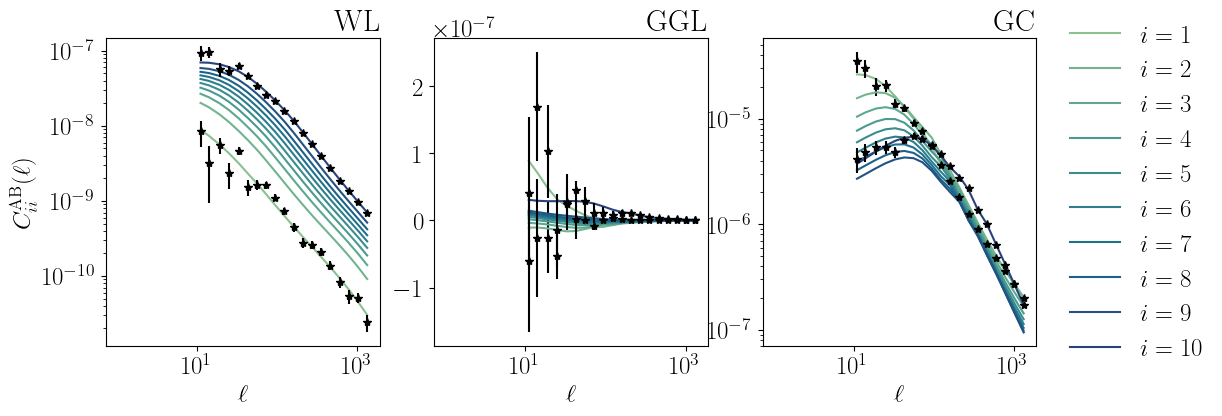

In [30]:
plot_err = [1,10]

fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
for i in range(1,11):
    if 'WL' in use_obs:
        axes[0].set_title('WL',loc='right')
        axes[0].plot(noiseless_cls['ells'],noiseless_cls['L{}xL{}'.format(i,i)],color=bincolors[i-1])
        if i in plot_err:
            axes[0].errorbar(noisy_cls['ells'],noisy_cls['L{}xL{}'.format(i,i)],
                             yerr=diag_error['L{}xL{}'.format(i,i)],color='black',ls='',marker='*')
        axes[0].set_xscale('log')
        axes[0].set_yscale('log')
        axes[0].set_ylabel(r'$C_{ii}^{\rm AB}(\ell)$')
        axes[0].set_xlabel(r'$\ell$')
    
    if 'WL' in use_obs and 'GC' in use_obs:
        axes[1].set_title('GGL',loc='right')
        axes[1].plot(noiseless_cls['ells'],noiseless_cls['G{}xL{}'.format(i,i)],color=bincolors[i-1])
        if i in plot_err:
            axes[1].errorbar(noisy_cls['ells'],noisy_cls['G{}xL{}'.format(i,i)],
                             yerr=diag_error['G{}xL{}'.format(i,i)],color='black',ls='',marker='*')
        axes[1].set_xscale('log')
        axes[1].set_xlabel(r'$\ell$')
    
    
    if 'GC' in use_obs:
        axes[2].set_title('GC',loc='right')
        axes[2].plot(noiseless_cls['ells'],noiseless_cls['G{}xG{}'.format(i,i)],color=bincolors[i-1],
                     label=r'$i={}$'.format(i))
        if i in plot_err:
            axes[2].errorbar(noisy_cls['ells'],noisy_cls['G{}xG{}'.format(i,i)],
                             yerr=diag_error['G{}xG{}'.format(i,i)],color='black',ls='',marker='*')
        axes[2].set_xscale('log')
        axes[2].set_yscale('log')    
        axes[2].set_xlabel(r'$\ell$')
    plt.legend(**sidelegend);

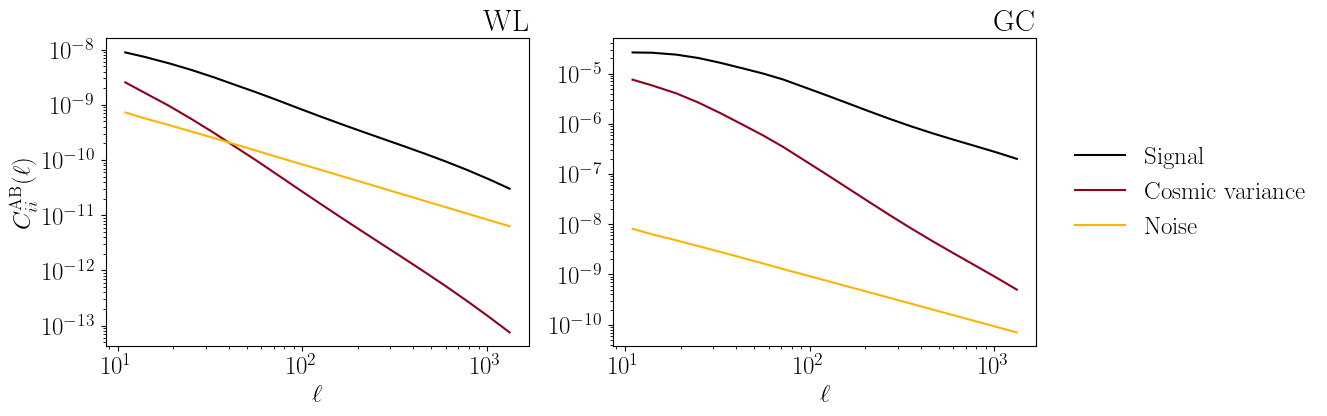

In [31]:
i = 1

norm = np.sqrt((2/((2*noiseless_cls['ells']+1)*Delta_ell*fsky)))

fig, axes = plt.subplots(ncols=2, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))

if 'WL' in use_obs:
    axes[0].set_title('WL',loc='right')
    axes[0].plot(noiseless_cls['ells'],noiseless_cls['L{}xL{}'.format(i,i)],color='black')
    axes[0].plot(noiseless_cls['ells'],norm*noiseless_cls['L{}xL{}'.format(i,i)],color=red)
    axes[0].plot(noiseless_cls['ells'],norm*Nell['L{}xL{}'.format(i,i)],color=yellow)
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_ylabel(r'$C_{ii}^{\rm AB}(\ell)$')
    axes[0].set_xlabel(r'$\ell$')


if 'GC' in use_obs:
    axes[1].set_title('GC',loc='right')
    axes[1].plot(noiseless_cls['ells'],noiseless_cls['G{}xG{}'.format(i,i)],color='black',label='Signal')
    axes[1].plot(noiseless_cls['ells'],norm*noiseless_cls['G{}xG{}'.format(i,i)],color=red,label='Cosmic variance')
    axes[1].plot(noiseless_cls['ells'],norm*Nell['G{}xG{}'.format(i,i)],color=yellow,label='Noise')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'$\ell$')
plt.legend(**sidelegend);

## Saving to file if requested

In [32]:
if data_root != '':
    noiseless_cls.to_csv(data_root+'_Cls_noiseless.dat',sep='\t',header=True)
    noisy_cls.to_csv(data_root+'_Cls_noisy.dat',sep='\t',header=True)
    np.save(data_root+'_source_distribution.npy',distributions)
    #np.save(data_root+'_gwdist.npy', distribution['GW'])
    np.save(data_root+'_covmat.npy',covmat_dict)